# NHANES — condiciones cronicas (tabla agregada)

## SECCIÓN 0 — DESCRIPCIÓN DEL DATASET

Datos **CDC/NHANES** en formato **CSV agregado** (no microdatos individuales). No hay archivo `.XPT` en esta carpeta; se usa `pd.read_csv`. Las filas son grupos poblacionales (año, sexo, edad, raza) y medidas de prevalencia.

### Tarea de machine learning
- **Tipo de tarea**: clasificación multiclase (predecir `Measure`: Obesity, Hypertension, etc.)
- **Variable objetivo**: `Measure` — tipo de condición crónica reportada.

Las siguientes celdas cargan datos y muestran `head`, `shape`, `dtypes` y `describe`.

In [1]:
import warnings  # Avisos
warnings.filterwarnings("ignore")  # Ocultar
from pathlib import Path  # Rutas
import numpy as np  # Numerico
import pandas as pd  # Tablas
import matplotlib.pyplot as plt  # Graficos
import seaborn as sns  # Stats
from IPython.display import display  # Jupyter
from sklearn.model_selection import train_test_split  # Split
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Escalado
from sklearn.linear_model import LinearRegression, LogisticRegression  # Modelos
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score  # Metricas
ROOT_NB = Path(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia")  # Raiz proyecto

df = pd.read_csv(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia/3. NHANES (National Health and Nutrition Examination Survey)/NHANES_Select_Chronic_Conditions_Prevalence_Estimates.csv")  # Cargar CSV
print("head:"); display(df.head(10))  # Muestra
print("shape:", df.shape)  # Forma
print("dtypes:\n", df.dtypes)  # Tipos
display(df.describe(include="all").T)  # Estadisticos


head:


,Survey Years,Sex,Age Group,Race and Hispanic Origin,Measure,Percent,Standard Error,Lower 95% CI Limit,Upper 95% CI Limit,Presentation Standard,Note1,Notea
0,1999-2000,All,20 and over,All,Obesity,30.3,1.5,27.2,33.5,NaN,NaN,NaN
1,1999-2000,Male,20 and over,All,Obesity,27.1,1.5,24.0,30.4,NaN,NaN,NaN
2,1999-2000,Female,20 and over,All,Obesity,33.3,1.7,29.6,37.1,NaN,NaN,NaN
3,1999-2000,All,20-29,All,Obesity,22.1,2.4,17.1,27.9,NaN,NaN,NaN
4,1999-2000,All,30-39,All,Obesity,29.2,2.1,24.8,33.9,NaN,NaN,NaN
5,1999-2000,All,40-49,All,Obesity,31.1,3.5,23.8,39.2,NaN,NaN,NaN
6,1999-2000,All,50-59,All,Obesity,36.7,3.3,29.7,44.2,NaN,NaN,NaN
7,1999-2000,All,60-69,All,Obesity,40.3,1.8,36.5,44.2,NaN,NaN,NaN
8,1999-2000,All,70 and over,All,Obesity,26.1,2.7,20.6,32.3,NaN,NaN,NaN
9,1999-2000,Male,20-29,All,Obesity,21.1,3.5,14.1,29.7,NaN,NaN,NaN


shape: (950, 12)
dtypes:
 Survey Years                    str
Sex                             str
Age Group                       str
Race and Hispanic Origin        str
Measure                         str
Percent                     float64
Standard Error              float64
Lower 95% CI Limit          float64
Upper 95% CI Limit          float64
Presentation Standard           str
Note1                           str
Notea                           str
dtype: object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Survey Years,950,10,1999-2000,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,950,3,All,450,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age Group,950,11,20 and over,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Race and Hispanic Origin,950,6,All,750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Measure,950,3,Obesity,430,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Percent,910.0,NaN,NaN,NaN,29.997912,18.694472,3.0,15.3,25.4,41.1,87.5
Standard Error,910.0,NaN,NaN,NaN,2.212308,0.99674,0.5,1.5,2.0,2.8,7.5
Lower 95% CI Limit,910.0,NaN,NaN,NaN,25.552418,17.753937,1.4,11.925,20.4,35.1,83.6
Upper 95% CI Limit,910.0,NaN,NaN,NaN,34.818242,19.406894,5.5,19.125,31.0,46.5,91.2
Presentation Standard,5,1,Estimate does not meet National Center for Hea...,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## SECCIÓN 1 — SANEAMIENTO

Mediana/modas; eliminar >40% nulos; sin duplicados exactos.

In [2]:
df1 = df.copy()  # Copia para limpiar
print("Nulos ANTES por columna (top):\n", df1.isnull().sum().sort_values(ascending=False).head(15))  # Conteo
df1 = df1.drop_duplicates()  # Eliminar filas duplicadas
nr = df1.isnull().mean()  # Fraccion nulos
drop_null = nr[nr > 0.40].index.tolist()  # Columnas >40% nulos
print("Eliminadas por >40% nulos:", drop_null)  # Motivo: poca informacion
df1 = df1.drop(columns=drop_null, errors="ignore")  # Borrar
num_cols = df1.select_dtypes(include=[np.number]).columns.tolist()  # Numericas
cat_cols = [c for c in df1.columns if c not in num_cols]  # Categoricas
for c in num_cols:
    df1[c] = df1[c].fillna(df1[c].median())  # Mediana (robusta a outliers)
for c in cat_cols:
    if df1[c].isnull().any():
        mod = df1[c].mode()
        df1[c] = df1[c].fillna(mod.iloc[0] if len(mod) else "")  # Moda
print("Nulos DESPUES (total):", int(df1.isnull().sum().sum()))  # Debe ser 0
assert df1.isnull().sum().sum() == 0
df_clean = df1.copy()


Nulos ANTES por columna (top):
 Presentation Standard       945
Note1                       910
Notea                       910
Percent                      40
Standard Error               40
Lower 95% CI Limit           40
Upper 95% CI Limit           40
Survey Years                  0
Race and Hispanic Origin      0
Age Group                     0
Sex                           0
Measure                       0
dtype: int64
Eliminadas por >40% nulos: ['Presentation Standard', 'Note1', 'Notea']
Nulos DESPUES (total): 0


## SECCIÓN 2 — X e y

**y** = `Measure` (3 clases). **X** = resto.

X.shape (950, 8) y.shape (950,)
Distribucion de clases:
 Measure
Obesity                   430
High Total Cholesterol    260
Hypertension              260
Name: count, dtype: int64


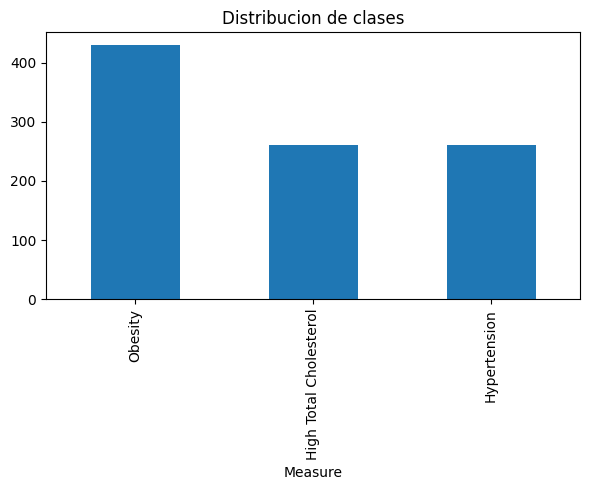

Top 5 correlaciones (aprox) con y: Upper 95% CI Limit    0.233724
Percent               0.224784
Lower 95% CI Limit    0.212844
Standard Error        0.175046
dtype: float64


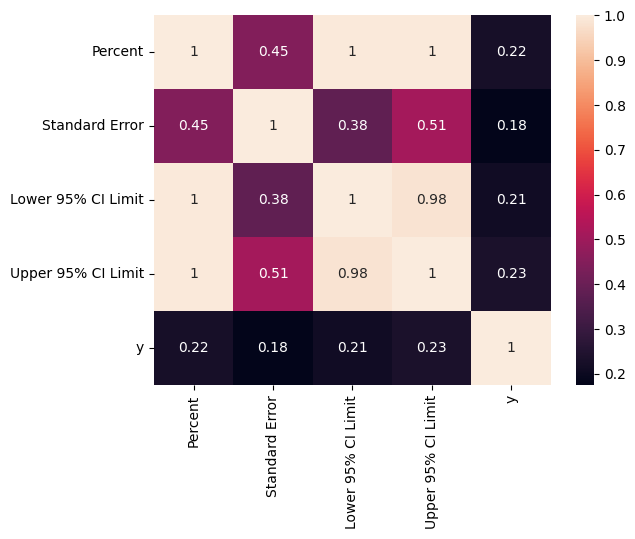

In [3]:
y = df_clean["Measure"]  # Tres clases  # Objetivo
X = df_clean.drop(columns=["Measure"])  # Features
print("X.shape", X.shape, "y.shape", y.shape)  # Dimensiones
print("Distribucion de clases:\n", y.value_counts())  # Conteos
plt.figure(figsize=(6,5))  # Figura
y.astype(str).value_counts().plot(kind="bar")  # Barras
plt.title("Distribucion de clases")  # Titulo
plt.tight_layout()  # Ajuste
plt.show()  # Mostrar
num_x = X.select_dtypes(include=[np.number]).columns  # Numericas
if len(num_x) > 0 and y.dtype != object:
    le = LabelEncoder()  # Codificar y para correlacion
    y_num = le.fit_transform(y.astype(str))  # y numerico
    corr = X[num_x].corrwith(pd.Series(y_num, index=X.index)).abs().sort_values(ascending=False)  # Correlaciones
    print("Top 5 correlaciones (aprox) con y:", corr.head(5))  # Top 5
    sns.heatmap(pd.concat([X[num_x[:min(5,len(num_x))]], pd.Series(y_num, name="y")], axis=1).corr(), annot=True)  # Mapa
    plt.show()
elif len(num_x) > 0:
    corr = X[num_x].apply(lambda s: pd.factorize(y)[0])  # Fallback


## SECCIÓN 3 — ENCODING

One-hot del resto de categorías; `Measure` ya separado como y.

In [4]:
X_enc = X.copy()  # Copia
non_num = [c for c in X_enc.columns if not pd.api.types.is_numeric_dtype(X_enc[c])]  # Categoricas
print("Categoricas (antes encoding):", non_num)  # Lista
X_enc = pd.get_dummies(X_enc, columns=non_num, drop_first=False)  # One-hot (nominal)
print("Columnas despues encoding:", X_enc.shape[1])  # Total
display(X_enc.head(5))  # Primeras filas


Categoricas (antes encoding): ['Survey Years', 'Sex', 'Age Group', 'Race and Hispanic Origin']
Columnas despues encoding: 34


,Percent,Standard Error,Lower 95% CI Limit,Upper 95% CI Limit,Survey Years_1999-2000,Survey Years_2001-2002,Survey Years_2003-2004,Survey Years_2005-2006,Survey Years_2007-2008,Survey Years_2009-2010,...,Age Group_50-59,Age Group_6-11,Age Group_60-69,Age Group_70 and over,Race and Hispanic Origin_All,Race and Hispanic Origin_Hispanic,Race and Hispanic Origin_Mexican American,Race and Hispanic Origin_Non-Hispanic Asian,Race and Hispanic Origin_Non-Hispanic Black,Race and Hispanic Origin_Non-Hispanic White
0,30.3,1.5,27.2,33.5,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,27.1,1.5,24.0,30.4,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,33.3,1.7,29.6,37.1,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,22.1,2.4,17.1,27.9,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,29.2,2.1,24.8,33.9,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


## SECCIÓN 4 — NORMALIZACIÓN

In [5]:
scaler = StandardScaler()  # Escalador
X_scaled = scaler.fit_transform(X_enc)  # Ajuste global
X_scaled_df = pd.DataFrame(X_scaled, columns=X_enc.columns, index=X_enc.index)  # DF
antes = X_enc.iloc[:5, :min(6, X_enc.shape[1])]  # 5 filas antes
despues = X_scaled_df.iloc[:5, :min(6, X_scaled_df.shape[1])]  # 5 filas despues
display(pd.concat([antes, despues], axis=1, keys=["ANTES","DESPUES"]))  # Comparativa


ANTES                                                       \
  Percent Standard Error Lower 95% CI Limit Upper 95% CI Limit   
0    30.3            1.5               27.2               33.5   
1    27.1            1.5               24.0               30.4   
2    33.3            1.7               29.6               37.1   
3    22.1            2.4               17.1               27.9   
4    29.2            2.1               24.8               33.9   

                                                  DESPUES                 \
  Survey Years_1999-2000 Survey Years_2001-2002   Percent Standard Error   
0                   True                  False  0.027072      -0.720719   
1                   True                  False -0.147697      -0.720719   
2                   True                  False  0.190918      -0.515786   
3                   True                  False -0.420773       0.201482   
4                   True                  False -0.033005      -0.105918   

                                                                \
  Lower 95% CI Limit Upper 95% CI Limit Survey Years_1999-2000   
0           0.107173          -0.060923                    3.0   
1          -0.076763          -0.224090                    3.0   
2           0.245124           0.128561                    3.0   
3          -0.473374          -0.355676                    3.0   
4          -0.030779          -0.039869                    3.0   

                          
  Survey Years_2001-2002  
0              -0.333333  
1              -0.333333  
2              -0.333333  
3              -0.333333  
4              -0.333333

## SECCIÓN 5 — SPLIT

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)  # Estratificado
print("Shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)  # Tamano


Shapes: (760, 34) (190, 34) (760,) (190,)


## SECCIÓN 6 — LogisticRegression

In [7]:
y_enc = LabelEncoder().fit_transform(y.astype(str))  # Etiquetas 0..K-1
clf = LogisticRegression(max_iter=1000)  # Clasificador
clf.fit(X_train, y_train)  # Entrenar (y string -> sklearn acepta)
acc = accuracy_score(y_test, clf.predict(X_test))  # Precision
print("Accuracy:", acc)  # Resultado
score_nhanes = acc  # Score


Accuracy: 0.8157894736842105


## SECCIÓN 7 — GUARDADO

In [8]:
out = Path(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia/3. NHANES (National Health and Nutrition Examination Survey)")  # Carpeta
pd.concat([X_scaled_df, y.rename("Measure")], axis=1).to_csv(out / "nhanes_clean.csv", index=False)  # Limpio
X_train.to_csv(out / "X_train.csv", index=False)  # Train
X_test.to_csv(out / "X_test.csv", index=False)  # Test
y_train.to_csv(out / "y_train.csv", index=True, header=True)  # y
y_test.to_csv(out / "y_test.csv", index=True, header=True)  # y test
print("Archivos guardados en", out)  # Ok


Archivos guardados en C:\Users\Hp\OneDrive\Escritorio\primerparcial_ia\3. NHANES (National Health and Nutrition Examination Survey)


## SECCIÓN 8 — RESUMEN

In [9]:
display(df_clean.head(10))  # Muestra
assert df_clean.isnull().sum().sum() == 0  # Sin nulos
assert np.all(np.isfinite(X_scaled_df.values))  # Finitos
print("RESUMEN NHANES | Accuracy:", round(acc, 4))  # Resumen


,Survey Years,Sex,Age Group,Race and Hispanic Origin,Measure,Percent,Standard Error,Lower 95% CI Limit,Upper 95% CI Limit
0,1999-2000,All,20 and over,All,Obesity,30.3,1.5,27.2,33.5
1,1999-2000,Male,20 and over,All,Obesity,27.1,1.5,24.0,30.4
2,1999-2000,Female,20 and over,All,Obesity,33.3,1.7,29.6,37.1
3,1999-2000,All,20-29,All,Obesity,22.1,2.4,17.1,27.9
4,1999-2000,All,30-39,All,Obesity,29.2,2.1,24.8,33.9
5,1999-2000,All,40-49,All,Obesity,31.1,3.5,23.8,39.2
6,1999-2000,All,50-59,All,Obesity,36.7,3.3,29.7,44.2
7,1999-2000,All,60-69,All,Obesity,40.3,1.8,36.5,44.2
8,1999-2000,All,70 and over,All,Obesity,26.1,2.7,20.6,32.3
9,1999-2000,Male,20-29,All,Obesity,21.1,3.5,14.1,29.7


RESUMEN NHANES | Accuracy: 0.8158
